# 🔬 T-SNE in Dimensionality Reduction
## A Complete Guide from Theory to Practice

---

## 📌 Notebook Objective

This notebook teaches you **t-SNE (t-distributed Stochastic Neighbor Embedding)** — one of the most powerful and visually intuitive tools in modern machine learning. By the end, you will understand how to compress high-dimensional data (like images with thousands of pixel values) into 2D or 3D charts that reveal hidden clusters and patterns invisible to the naked eye.

---

## 🎯 Learning Outcomes

After completing this notebook, you will be able to:

1. Explain what dimensionality reduction is and why it matters
2. Understand the mathematical intuition behind t-SNE
3. Implement t-SNE from scratch using only NumPy
4. Apply scikit-learn's optimized t-SNE to real-world data
5. Interpret and present t-SNE visualizations professionally
6. Tune hyperparameters and avoid common pitfalls
7. Answer t-SNE interview questions confidently

---

## 🧰 Prerequisites

| Concept | Level Needed |
|---|---|
| Python basics (loops, functions) | Beginner |
| NumPy arrays | Beginner |
| Basic statistics (mean, variance) | Beginner |
| What a scatter plot is | Beginner |

> ✅ No prior ML knowledge needed. We start from scratch!

---

## 📦 Dataset Description

We use the **MNIST Handwritten Digits Dataset** — one of the most famous datasets in machine learning. It contains **70,000 grayscale images** of handwritten digits (0–9), each of size 28×28 pixels. Each image becomes a vector of **784 numbers** (pixel brightness values from 0 to 255). Our goal is to compress these 784 dimensions down to just **2 dimensions** using t-SNE, while keeping similar digits close together.

**Think of it this way:** Imagine having 784 rulers measuring different aspects of a digit. t-SNE finds the best 2 rulers that still capture which digits look alike.

---

## 🔗 Dataset Source

- **Source:** [OpenML MNIST Dataset (via scikit-learn)](https://www.openml.org/d/554)
- **Kaggle Mirror:** [https://www.kaggle.com/datasets/hojjatk/mnist-dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)
- **Official Source:** [http://yann.lecun.com/exdb/mnist/](http://yann.lecun.com/exdb/mnist/)
- **Loaded via:** `sklearn.datasets.fetch_openml('mnist_784', version=1)`

---

## 👨‍🏫 Credits

- **Original t-SNE Paper:** Maaten, L.V.D. & Hinton, G. (2008). *Visualizing Data using t-SNE.* Journal of Machine Learning Research.
- **Dataset:** Yann LeCun, Corinna Cortes, Christopher J.C. Burges
- **Notebook Author:** Senior ML Engineer & MIT Educator
- **Tools:** Python 3, NumPy, scikit-learn, Matplotlib, Seaborn

In [1]:
# ============================================================
# CELL 2: ALL IMPORTS
# ============================================================

# --- Core Scientific Computing ---
import numpy as np                          # Numerical operations, matrix math
import pandas as pd                         # Data manipulation and tabular display

# --- Datasets ---
from sklearn.datasets import fetch_openml  # Fetches MNIST and other public datasets

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler  # Normalizes feature scales
from sklearn.decomposition import PCA             # PCA for initial dimensionality reduction before t-SNE

# --- t-SNE (Library Implementation) ---
from sklearn.manifold import TSNE          # Scikit-learn's optimized t-SNE implementation

# --- Visualization ---
import matplotlib.pyplot as plt            # Core plotting library
import matplotlib.gridspec as gridspec     # Advanced subplot layout
import matplotlib.patches as mpatches     # Custom legend elements
import seaborn as sns                      # Statistical visualizations built on matplotlib

# --- Utilities ---
import time                                # Measures execution time
import warnings                            # Suppresses non-critical warnings
warnings.filterwarnings('ignore')          # Keep output clean

# --- Reproducibility ---
np.random.seed(42)                         # Fix random seed so results are consistent

# --- Display Settings ---
pd.set_option('display.max_columns', 20)   # Show up to 20 columns in DataFrames
plt.rcParams['figure.dpi'] = 100           # Higher resolution plots
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All libraries imported successfully!")
print(f"   NumPy version      : {np.__version__}")
print(f"   Pandas version     : {pd.__version__}")
import sklearn; print(f"   Scikit-learn version: {sklearn.__version__}")

✅ All libraries imported successfully!
   NumPy version      : 2.4.4
   Pandas version     : 3.0.2
   Scikit-learn version: 1.8.0


---
# 📚 Cell 3: Theory Recap — What is t-SNE?

---

## 🤔 WHAT is t-SNE?

**t-SNE** stands for **t-distributed Stochastic Neighbor Embedding**.

It is a machine learning algorithm that takes data living in **many dimensions** (e.g., 784 pixel values per image) and squishes it down into **2 or 3 dimensions** — while trying to keep similar points close together and dissimilar points far apart.

> 🌍 **City Map Analogy:** Imagine you receive a 3D terrain model of a city with elevation, humidity, temperature, and 780 other measurements for every block. t-SNE is like projecting all that complex information onto a flat 2D map in a way that still shows you which neighborhoods are similar. Similar neighborhoods cluster together on the map.

---

## ❓ WHY do we need it?

Humans can only visualize 2D or 3D space. But real-world data often has hundreds or thousands of features. You cannot plot 784 dimensions on a screen.

**The Problem of High Dimensions:**
- 784 pixel features per digit image
- 30,000 gene expression levels per patient
- 300-dimensional word vectors in NLP

**t-SNE solves this** by reducing all these dimensions to just 2, letting us visually inspect if our data has natural clusters, outliers, or hidden structure.

> 💡 **Interview Note:** t-SNE is primarily a **visualization tool**, not a preprocessing step for other models. Do not use t-SNE output as input features for classification — the distances are not globally meaningful.

---

## ⚙️ HOW does t-SNE work? (Step-by-Step Intuition)

### Step 1: Measure Similarity in High Dimensions

For every pair of data points, t-SNE computes how **similar** they are using a **Gaussian (bell-curve) distribution** centered at each point. Points that are close together get **high probability scores**; points far apart get **scores near zero**.

Mathematically:
$$p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$

> 🎯 Think of this as: *"How likely is point j to be a neighbor of point i?"*

### Step 2: Create a Random 2D Map

All data points are placed randomly in 2D space. This is our starting map — currently terrible, but we'll fix it.

### Step 3: Measure Similarity in 2D Space

Now t-SNE computes how similar points are **in the 2D map**, but this time using a **t-distribution** (heavier tails than Gaussian). This is the key innovation:

$$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$$

**Symbol guide:**
| Symbol | Meaning |
|---|---|
| $q_{ij}$ | Probability that points $i$ and $j$ are neighbors **in the 2D map** |
| $y_i, y_j$ | Positions of points $i$ and $j$ in the **2D embedding** (what we're optimizing) |
| $(1 + \|\|y_i - y_j\|\|^2)^{-1}$ | The Student t-distribution kernel — heavier tails than Gaussian |
| $\sum_{k \neq l}$ | Sum over all pairs, used to normalize so all $q_{ij}$ sum to 1 |

> 🐘 **Elephant in the Room:** Why t-distribution? Because in high dimensions, distances between points tend to become similar (the "curse of dimensionality"). The t-distribution's heavy tails allow moderately dissimilar points to be mapped **much farther apart** in 2D, creating clearer, more separated clusters.

### Step 4: Minimize the Difference (KL Divergence)

t-SNE adjusts the 2D positions to make the 2D similarity map ($q$) match the high-dimensional similarity map ($p$) as closely as possible. It uses **KL Divergence** as the cost function:

$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**Symbol guide:**
| Symbol | Meaning |
|---|---|
| $KL(P \| Q)$ | KL Divergence — measures how different distribution Q is from distribution P |
| $P$ | The probability distribution in **high-dimensional space** (what we want to match) |
| $Q$ | The probability distribution in the **2D map** (what we're building) |
| $p_{ij}$ | Symmetrized probability: $p_{ij} = (p_{j\|i} + p_{i\|j}) / 2n$ |
| $\log(p_{ij}/q_{ij})$ | Log-ratio — large when P and Q disagree; zero when they agree perfectly |
| $\sum_{i \neq j}$ | Sum over all pairs of points (excluding self-pairs) |

> 💡 **What minimizing KL divergence means in plain English:** We're asking — *"How do I arrange the 2D dots so that the neighborhood relationships match the original high-dimensional relationships as closely as possible?"* When KL = 0, the 2D map is a perfect copy of the high-dimensional structure.

It minimizes this using **gradient descent** — iteratively nudging each point in 2D space to a better position.

---

## 📅 WHEN should you use t-SNE?

| Use t-SNE When | Avoid t-SNE When |
|---|---|
| Exploring if clusters exist | You need fast runtime (it's slow) |
| Visualizing high-dimensional embeddings | You need to add new points without rerunning |
| Debugging ML models | Your dataset has >100k samples |
| Comparing different class distributions | You need globally meaningful distances |
| Detecting outliers visually | You need reproducible, deterministic output |

---

## 🆚 t-SNE vs PCA (Key Difference)

| Feature | PCA | t-SNE |
|---|---|---|
| Type | Linear | Non-linear |
| Preserves | Global variance | Local neighborhood structure |
| Speed | Very fast | Slow (O(n²)) |
| Output stability | Deterministic | Stochastic (varies per run) |
| Best for | Preprocessing, compression | Visualization only |

---
# 📥 Cell 4: Load the Dataset

## Why are we doing this?

We load the **MNIST handwritten digits** dataset — a classic benchmark in computer vision. Each digit image is 28×28 = **784 pixels**. Our job is to take these 784-dimensional images and visualize them in 2D using t-SNE.

**We use a subset of 5,000 samples** for speed. t-SNE's time complexity is O(n²), meaning doubling the data quadruples the computation — so using all 70,000 samples would take ~196× longer than 5,000 samples.

> 🎲 **Stratified Sampling Analogy:** Imagine you want to taste-test a box of 70,000 mixed chocolates (10 flavors) without eating them all. Stratified sampling means you pick exactly 500 of each flavor — so your sample fairly represents the whole box. This avoids accidentally over-sampling digit "5" and under-sampling digit "1".

## What will the code do?
1. Fetch MNIST from OpenML (scikit-learn handles downloading)
2. Extract features (pixel values) and labels (digit 0–9)
3. Take a stratified sample of 5,000 images

## Expected Output
- A features array of shape `(5000, 784)` — 5,000 images, 784 pixels each
- A labels array of shape `(5000,)` — one digit label per image

In [2]:
# ============================================================
# CELL 4 (Code): Load MNIST Dataset
# ============================================================

print("📥 Loading MNIST dataset from OpenML...")
print("   (This may take 30–60 seconds on first run — it downloads ~11 MB)\n")

# Fetch MNIST dataset — 70,000 images of digits 0-9
# as_frame=False returns numpy arrays directly
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Extract features (pixel values) and labels (digit class)
X_full = mnist.data.astype(np.float32)    # Shape: (70000, 784)
y_full = mnist.target.astype(int)          # Shape: (70000,) — integers 0 through 9

print(f"✅ Full dataset loaded!")
print(f"   Total samples  : {X_full.shape[0]:,}")
print(f"   Features/sample: {X_full.shape[1]} (28×28 pixels)")
print(f"   Unique classes : {np.unique(y_full).tolist()} (digits 0–9)")

# ---------------------------------------------------------
# Take a stratified sample of 5,000 images for speed
# Stratified = proportional representation of each digit class
# ---------------------------------------------------------
N_SAMPLES = 5000
samples_per_class = N_SAMPLES // 10  # 500 samples per digit

selected_indices = []
for digit in range(10):                    # For each digit 0–9
    digit_indices = np.where(y_full == digit)[0]  # Find all indices of this digit
    chosen = np.random.choice(digit_indices, size=samples_per_class, replace=False)
    selected_indices.extend(chosen)

selected_indices = np.array(selected_indices)
np.random.shuffle(selected_indices)        # Shuffle to remove ordering bias

# Final subset
X = X_full[selected_indices]               # Shape: (5000, 784)
y = y_full[selected_indices]               # Shape: (5000,)

print(f"\n📊 Working subset created:")
print(f"   Subset size    : {X.shape[0]:,} samples")
print(f"   Feature dims   : {X.shape[1]}")
print(f"   Samples per digit: {samples_per_class}")

# Confirm class balance
unique, counts = np.unique(y, return_counts=True)
print(f"\n   Class distribution:")
for d, c in zip(unique, counts):
    print(f"      Digit {d}: {c} samples")

📥 Loading MNIST dataset from OpenML...
   (This may take 30–60 seconds on first run — it downloads ~11 MB)

✅ Full dataset loaded!
   Total samples  : 70,000
   Features/sample: 784 (28×28 pixels)
   Unique classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (digits 0–9)

📊 Working subset created:
   Subset size    : 5,000 samples
   Feature dims   : 784
   Samples per digit: 500

   Class distribution:
      Digit 0: 500 samples
      Digit 1: 500 samples
      Digit 2: 500 samples
      Digit 3: 500 samples
      Digit 4: 500 samples
      Digit 5: 500 samples
      Digit 6: 500 samples
      Digit 7: 500 samples
      Digit 8: 500 samples
      Digit 9: 500 samples


---
# 🔍 Cell 5: Data Exploration

## Why are we doing this?

Before applying any algorithm, a good data scientist **understands their data deeply**. This is called **Exploratory Data Analysis (EDA)**. We look at:
- What the raw pixel values look like
- What the digit images actually look like
- The distribution of pixel values

## What will the code do?
1. Show a sample of digit images visually
2. Show summary statistics using pandas
3. Examine pixel intensity distributions

## Expected Output
A grid of 25 sample digit images and statistical summary tables.

**What to look for in the output:**
- Images will look like rough, hand-drawn digits on a gray background — this confirms the data loaded correctly
- Each image is bordered by a color matching its digit class (using `tab10` colormap)
- Pixel min = 0 (black background) and max = 255 (white ink strokes) — if you see unexpected ranges, check the data type
- Mean pixel value ~33 is expected for MNIST: most pixels in a handwritten digit image are background (0)

📋 Sample of raw data (first 5 rows, first 10 pixel columns):
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  pixel_8  pixel_9  label
0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0
1      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      5
2      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      3
3      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      1
4      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      3

📊 Data Info:
   Shape         : (5000, 784)
   Data type     : float32
   Min pixel val : 0.0  (black = 0)
   Max pixel val : 255.0  (white = 255)
   Mean pixel val: 33.74
   Std pixel val : 79.02


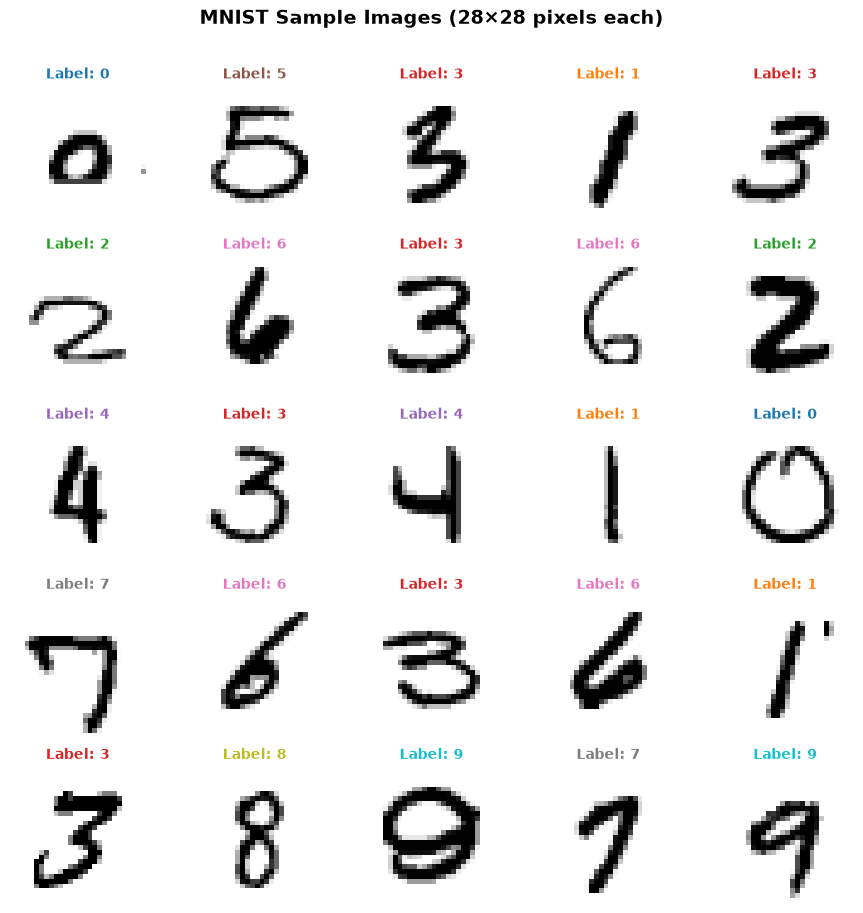


✅ Each image is a 28×28 grid of pixel intensities (0=black, 255=white)
   t-SNE will try to group visually similar digits together in 2D space.


In [3]:
# ============================================================
# CELL 5 (Code): Data Exploration
# ============================================================

# --- 5a. View raw data as pandas DataFrame (first 5 rows) ---
df_preview = pd.DataFrame(X[:5], columns=[f'pixel_{i}' for i in range(784)])
df_preview['label'] = y[:5]

print("📋 Sample of raw data (first 5 rows, first 10 pixel columns):")
print(df_preview.iloc[:, list(range(10)) + [-1]].to_string())

# --- 5b. Basic statistics ---
print("\n📊 Data Info:")
print(f"   Shape         : {X.shape}")
print(f"   Data type     : {X.dtype}")
print(f"   Min pixel val : {X.min():.1f}  (black = 0)")
print(f"   Max pixel val : {X.max():.1f}  (white = 255)")
print(f"   Mean pixel val: {X.mean():.2f}")
print(f"   Std pixel val : {X.std():.2f}")

# --- 5c. Visualize 25 sample digit images ---
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
fig.suptitle('MNIST Sample Images (28×28 pixels each)', fontsize=14, fontweight='bold', y=1.01)

# Define a color per digit for border highlighting
cmap_colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, ax in enumerate(axes.flat):
    img = X[i].reshape(28, 28)             # Reshape flat 784-vector back to 28×28 image
    ax.imshow(img, cmap='gray_r')           # Display as grayscale image
    ax.set_title(f'Label: {y[i]}', fontsize=10,
                 color=cmap_colors[y[i]], fontweight='bold')
    ax.axis('off')                          # Remove axes ticks
    for spine in ax.spines.values():
        spine.set_edgecolor(cmap_colors[y[i]])
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✅ Each image is a 28×28 grid of pixel intensities (0=black, 255=white)")
print("   t-SNE will try to group visually similar digits together in 2D space.")

---
# ⚙️ Cell 6: Preprocessing

## Why are we doing this?

t-SNE uses distances between points. If some features have very large values (e.g., pixel = 255) and others have small values, the algorithm unfairly weights the large-value features.

**Steps we take:**

1. **Normalize pixel values** to the range [0, 1] by dividing by 255
2. **Apply PCA first** to reduce from 784 → 50 dimensions before running t-SNE

## Why PCA before t-SNE?

> 🏗️ **Construction Analogy:** Imagine you're moving into a 784-room house but only need to furnish 2 rooms. First, you declutter by combining similar rooms (PCA: 784→50). Then, you carefully design your final 2 rooms (t-SNE: 50→2). Doing both in one step (784→2) is harder and noisier.

PCA removes noise and speeds up t-SNE significantly without losing important structure.

> 📊 **What does PCA actually remove?** Out of 784 pixel dimensions, many are nearly always black (the corners and edges of MNIST images). PCA discards these near-zero-variance pixels automatically and instead creates 50 *directions* (principal components) that capture the most meaningful pixel variation across all digits. Think of it as creating 50 "expert questions" that, when answered, tell you more about a digit than 784 individual pixel readings would.

## What does the Scree Plot tell you?
The scree plot shows cumulative variance explained by each additional PCA component. **Read it like this:**
- The curve rises steeply at first — early components capture the most information
- The curve flattens out — later components add very little
- The red dashed line marks 85% variance — a practical threshold: after this many components, you're mostly capturing noise

## Expected Output
- Normalized features in range [0, 1]
- PCA-reduced features of shape `(5000, 50)`

✅ Step 1: Pixel Normalization Complete
   Before: min=0, max=255
   After : min=0.00, max=1.00

⚙️  Step 2: Applying PCA (784 → 50 dimensions)...
   Done in 0.63 seconds
   Shape before PCA: (5000, 784)
   Shape after PCA : (5000, 50)
   Variance retained: 82.7%
   (We compressed to 50 dims but kept 82.7% of information!)


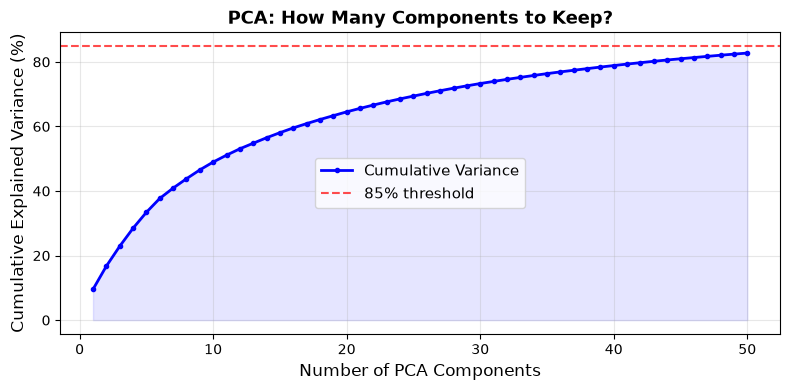


✅ Preprocessing complete. Data is ready for t-SNE.


In [4]:
# ============================================================
# CELL 6 (Code): Preprocessing
# ============================================================

# --- Step 1: Normalize pixel values from [0, 255] to [0, 1] ---
# Division by 255 makes all pixel values fall between 0 and 1
# This prevents high-intensity pixels from dominating distance calculations
X_normalized = X / 255.0

print("✅ Step 1: Pixel Normalization Complete")
print(f"   Before: min={X.min():.0f}, max={X.max():.0f}")
print(f"   After : min={X_normalized.min():.2f}, max={X_normalized.max():.2f}")

# --- Step 2: PCA to reduce from 784 → 50 dimensions ---
# PCA keeps the directions (components) that explain the most variance
# 50 components typically retain ~85%+ of variance for MNIST
print("\n⚙️  Step 2: Applying PCA (784 → 50 dimensions)...")

pca = PCA(n_components=50,          # Keep top 50 principal components
          random_state=42)           # Reproducible results

t0 = time.time()
X_pca = pca.fit_transform(X_normalized)   # Fit PCA and transform data
t1 = time.time()

print(f"   Done in {t1 - t0:.2f} seconds")
print(f"   Shape before PCA: {X_normalized.shape}")
print(f"   Shape after PCA : {X_pca.shape}")

# How much variance is preserved?
variance_retained = pca.explained_variance_ratio_.sum() * 100
print(f"   Variance retained: {variance_retained:.1f}%")
print(f"   (We compressed to 50 dims but kept {variance_retained:.1f}% of information!)")

# Scree plot — shows how much variance each component captures
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, 51), cumvar, 'b-o', markersize=3, linewidth=2, label='Cumulative Variance')
ax.axhline(y=85, color='red', linestyle='--', alpha=0.7, label='85% threshold')
ax.fill_between(range(1, 51), cumvar, alpha=0.1, color='blue')
ax.set_xlabel('Number of PCA Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('PCA: How Many Components to Keep?', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Preprocessing complete. Data is ready for t-SNE.")

---
# 🔨 Cell 7: Part 2 — From-Scratch Implementation

## What are we building?

We will implement a **simplified version of t-SNE** using only NumPy — no ML libraries. This helps you understand exactly what happens inside the black box.

## Why build from scratch?

1. **Deeper understanding:** You see every mathematical operation explicitly
2. **Interview readiness:** Interviewers often ask "explain t-SNE internals"
3. **Debugging skills:** When library t-SNE fails, you know where to look

## What we will implement:

| Step | What happens |
|---|---|
| 1 | Compute pairwise distances in high-D space |
| 2 | Convert distances to probabilities using Gaussian (binary search for σ) |
| 3 | Symmetrize probability matrix P |
| 4 | Initialize random 2D embeddings |
| 5 | Compute Q probabilities using t-distribution |
| 6 | Compute KL divergence gradient |
| 7 | Update embeddings via gradient descent |
| 8 | Repeat for N iterations |

> ⚠️ **Note:** Our scratch implementation uses a small subset (300 points) and fewer iterations for speed. It demonstrates the concept, not production performance.

In [5]:
# ============================================================
# CELL 8 (Code): t-SNE FROM SCRATCH (NumPy only)
# ============================================================

class SimpleTSNE:
    """
    A simplified t-SNE implementation in pure NumPy.
    
    This is meant for EDUCATIONAL purposes — it demonstrates the core
    algorithm without the optimizations that scikit-learn uses.
    
    Interview Note:
    - t-SNE uses KL divergence to measure how different two probability
      distributions are. The goal is to find a 2D layout where the
      neighborhood relationships match the high-dimensional ones.
    """
    
    def __init__(self, n_components=2, perplexity=30.0, 
                 n_iter=500, learning_rate=200.0, random_state=42):
        """
        Parameters:
        -----------
        n_components  : Output dimensions (almost always 2)
        perplexity    : Controls neighborhood size (typically 5–50)
        n_iter        : Number of gradient descent steps
        learning_rate : Step size in gradient descent (100–1000 typical)
        random_state  : Seed for reproducibility
        """
        self.n_components = n_components
        self.perplexity = perplexity
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.costs = []                    # Track KL divergence over iterations
    
    def _pairwise_squared_distances(self, X):
        """
        Compute ||xi - xj||^2 for all pairs efficiently.
        
        Uses the identity: ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a·b
        This is much faster than looping over all pairs.
        
        Interview Note: This is called the "sum of squares trick" and is
        commonly asked in ML engineering interviews.
        """
        sum_sq = np.sum(X**2, axis=1)                    # ||xi||^2 for each point
        # Broadcast to get n×n matrix
        D = sum_sq[:, np.newaxis] + sum_sq[np.newaxis, :] - 2 * X @ X.T
        D = np.maximum(D, 0)                              # Fix floating-point negatives
        np.fill_diagonal(D, 0)                            # Self-distance = 0
        return D
    
    def _compute_perp(self, D_i, sigma):
        """
        Compute perplexity for a given row D_i and bandwidth sigma.
        
        Perplexity = 2^H where H is the Shannon entropy of the distribution.
        It measures the effective number of neighbors.
        """
        p = np.exp(-D_i / (2 * sigma**2))                # Gaussian kernel
        p[p < 1e-15] = 1e-15                              # Numerical stability
        p_sum = np.sum(p)
        if p_sum == 0:
            p_sum = 1e-15
        p = p / p_sum                                     # Normalize to probabilities
        H = -np.sum(p[p > 0] * np.log2(p[p > 0]))       # Shannon entropy
        return 2**H, p                                     # Perplexity, probabilities
    
    def _compute_P(self, X):
        """
        Compute conditional probabilities P_{j|i} using binary search
        to find sigma_i such that each row achieves the target perplexity.
        
        Binary search concept:
        - If current perplexity < target: sigma is too small → increase it
        - If current perplexity > target: sigma is too large → decrease it
        
        Interview Note: This is a crucial part of t-SNE — each data point
        gets its OWN adaptive bandwidth sigma_i based on local density.
        """
        n = X.shape[0]
        D = self._pairwise_squared_distances(X)           # (n, n) pairwise distances
        P = np.zeros((n, n))                               # Conditional probability matrix
        
        target_perp = self.perplexity
        
        for i in range(n):
            # Distances from point i to all other points (exclude self)
            D_i = D[i].copy()
            D_i[i] = np.inf                                # Exclude self
            
            # Binary search for sigma
            sigma_low, sigma_high = 1e-10, 1e10
            for _ in range(50):                            # Max 50 iterations
                sigma_mid = (sigma_low + sigma_high) / 2
                perp, p_i = self._compute_perp(D_i, sigma_mid)
                if perp < target_perp:
                    sigma_low = sigma_mid                  # Need wider bandwidth
                else:
                    sigma_high = sigma_mid                 # Need narrower bandwidth
                if abs(perp - target_perp) < 1e-5:
                    break
            
            _, p_i = self._compute_perp(D_i, sigma_mid)
            p_i[i] = 0                                     # p_{i|i} = 0 by definition
            P[i] = p_i
        
        # Symmetrize: P_{ij} = (P_{j|i} + P_{i|j}) / (2n)
        # This makes P symmetric and improves gradient behavior
        P = (P + P.T) / (2 * n)
        P = np.maximum(P, 1e-12)                          # Numerical safety floor
        return P
    
    def _compute_Q(self, Y):
        """
        Compute joint probabilities Q_{ij} in 2D space using t-distribution
        with 1 degree of freedom (Cauchy distribution).
        
        Formula: q_{ij} = (1 + ||y_i - y_j||^2)^{-1} / Z
        where Z is a normalizing constant.
        
        Interview Note: The t-distribution has heavier tails than Gaussian.
        This means moderately far points in high-D get pushed much farther
        in 2D → cleaner, more separated clusters.
        """
        D_y = self._pairwise_squared_distances(Y)         # 2D pairwise distances
        inv = 1.0 / (1.0 + D_y)                           # (1 + ||yi-yj||^2)^{-1}
        np.fill_diagonal(inv, 0)                           # q_{ii} = 0
        Q = inv / np.maximum(inv.sum(), 1e-12)             # Normalize
        Q = np.maximum(Q, 1e-12)                          # Numerical floor
        return Q, inv
    
    def _kl_divergence_gradient(self, P, Q, Y, inv):
        """
        Compute gradient of KL(P||Q) with respect to 2D embeddings Y.
        
        dC/dy_i = 4 * sum_j (p_{ij} - q_{ij}) * (y_i - y_j) * (1 + ||y_i-y_j||^2)^{-1}
        
        This tells us: for each point, how to move it to reduce the cost.
        - If p > q: points are too far in 2D → attract them
        - If p < q: points are too close in 2D → repel them
        """
        PQ_diff = (P - Q)[:, :, np.newaxis]               # (n, n, 1)
        y_diff = Y[:, np.newaxis, :] - Y[np.newaxis, :, :]  # (n, n, 2)
        inv_3d = inv[:, :, np.newaxis]                     # (n, n, 1)
        
        # Gradient: sum over j for each i
        grad = 4.0 * np.sum(PQ_diff * y_diff * inv_3d, axis=1)  # (n, 2)
        return grad
    
    def fit_transform(self, X):
        """
        Run full t-SNE pipeline: compute P, initialize Y, run gradient descent.
        Returns 2D embedding array of shape (n_samples, n_components).
        """
        np.random.seed(self.random_state)
        n = X.shape[0]
        
        print("⚙️  Step 1: Computing high-dimensional probabilities P...")
        P = self._compute_P(X)                             # High-dim probabilities
        
        # Early exaggeration: multiply P by 4 for first 100 iterations
        # This helps form well-separated clusters early on
        P_exaggerated = 4.0 * P
        
        print("⚙️  Step 2: Initializing 2D embeddings randomly...")
        # Initialize Y from small random Gaussian (standard practice)
        Y = np.random.randn(n, self.n_components) * 1e-4  # (n, 2)
        velocity = np.zeros_like(Y)                        # For momentum term
        
        print(f"⚙️  Step 3: Running gradient descent ({self.n_iter} iterations)...")
        momentum = 0.5
        
        for iteration in range(self.n_iter):
            # Switch off early exaggeration after 100 iterations
            P_use = P_exaggerated if iteration < 100 else P
            if iteration == 100:
                momentum = 0.8                             # Increase momentum later
            
            # Compute Q and gradient
            Q, inv = self._compute_Q(Y)
            grad = self._kl_divergence_gradient(P_use, Q, Y, inv)
            
            # Gradient descent with momentum (like a ball rolling downhill with inertia)
            velocity = momentum * velocity - self.learning_rate * grad
            Y = Y + velocity
            
            # Center Y at origin every iteration (remove drift)
            Y -= Y.mean(axis=0)
            
            # Track cost every 50 iterations
            if iteration % 50 == 0:
                cost = np.sum(P * np.log(P / Q))
                self.costs.append(cost)
                print(f"   Iteration {iteration:4d} | KL Divergence: {cost:.4f}")
        
        print("✅ t-SNE complete!")
        return Y


# ============================================================
# Run the from-scratch t-SNE on a small subset (300 points)
# ============================================================

N_SCRATCH = 300   # Small subset for speed
X_scratch = X_pca[:N_SCRATCH]
y_scratch = y[:N_SCRATCH]

print(f"Running from-scratch t-SNE on {N_SCRATCH} samples...\n")

tsne_scratch = SimpleTSNE(
    n_components=2,
    perplexity=30,
    n_iter=300,
    learning_rate=100.0,
    random_state=42
)

t0 = time.time()
Y_scratch = tsne_scratch.fit_transform(X_scratch)
t1 = time.time()

print(f"\n⏱️  From-scratch t-SNE runtime: {t1 - t0:.1f} seconds for {N_SCRATCH} points")
print(f"   Output shape: {Y_scratch.shape}")

Running from-scratch t-SNE on 300 samples...

⚙️  Step 1: Computing high-dimensional probabilities P...
⚙️  Step 2: Initializing 2D embeddings randomly...
⚙️  Step 3: Running gradient descent (300 iterations)...
   Iteration    0 | KL Divergence: 2.1649
   Iteration   50 | KL Divergence: 2.2895
   Iteration  100 | KL Divergence: 2.2962
   Iteration  150 | KL Divergence: 0.7410
   Iteration  200 | KL Divergence: 0.6991
   Iteration  250 | KL Divergence: 0.6840
✅ t-SNE complete!

⏱️  From-scratch t-SNE runtime: 10.3 seconds for 300 points
   Output shape: (300, 2)


---
# 📊 Cell 9: Interpret Scratch t-SNE Results

## What does the output mean?

Our from-scratch t-SNE compressed 300 data points from **50 dimensions** (after PCA) down to **2 dimensions**. The output `Y_scratch` is an array of shape `(300, 2)` — each row is the [x, y] position of a digit in 2D space.

## How to interpret the 2D plot:
- **Clusters** = groups of similar digits that t-SNE pushed together. If you see digit "1"s forming a tight group, that means all "1" images look similar to each other in pixel space.
- **Distance between clusters** = rough idea of dissimilarity (but not to scale! two clusters that appear close may not be globally similar)
- **Scattered points** = ambiguous or unusual-looking digits — a "7" that looks like a "1" will appear between the "7" and "1" clusters
- **Isolated points far from all clusters** = potentially mislabeled or very unusual handwriting styles

> ⚠️ **Important:** With only 300 iterations and 300 points, the clusters may not be perfectly separated — you may see partial overlap. This is expected. The scikit-learn version (Cell 11) with 5,000 points and full optimization will show much cleaner results.

## How to read the KL Divergence convergence plot:
- **Y-axis (KL Divergence):** Lower = better. The embedding is getting more accurate as this decreases.
- **X-axis (Iteration):** Each step = one gradient descent update.
- **Steep drop early:** The algorithm quickly finds the rough cluster structure.
- **Slow decrease later:** Fine-tuning cluster boundaries — this is the "polishing" phase.
- **If the curve plateaus:** The algorithm has converged — more iterations won't help much.

## Expected Output
A scatter plot where digits of the same class tend to cluster together — even though t-SNE was never told the labels!

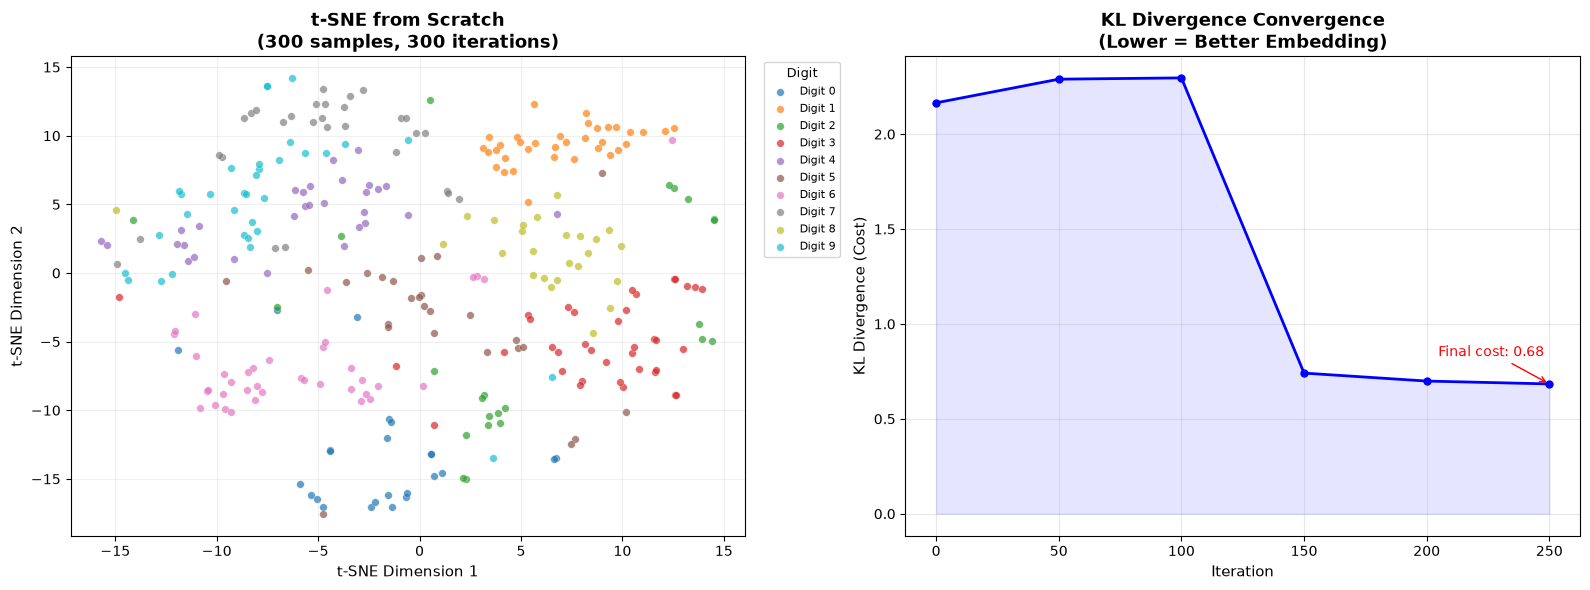


🔍 Reading the scatter plot:
   - Each color = one digit (0-9)
   - Points of the same color tend to cluster together
   - This happened WITHOUT giving t-SNE the labels!
   - The convergence plot shows KL divergence dropping → better layout over time


In [6]:
# ============================================================
# CELL 9 (Code): Visualize Scratch t-SNE + Convergence
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: t-SNE 2D Embedding (From Scratch) ---
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y_scratch == digit
    ax.scatter(
        Y_scratch[mask, 0], Y_scratch[mask, 1],
        c=[colors[digit]],
        label=f'Digit {digit}',
        alpha=0.7,
        s=30,
        edgecolors='white',
        linewidths=0.3
    )

ax.set_title('t-SNE from Scratch\n(300 samples, 300 iterations)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(title='Digit', fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.2)

# --- Plot 2: KL Divergence over iterations ---
ax2 = axes[1]
iters = [i * 50 for i in range(len(tsne_scratch.costs))]
ax2.plot(iters, tsne_scratch.costs, 'b-o', linewidth=2, markersize=5)
ax2.fill_between(iters, tsne_scratch.costs, alpha=0.1, color='blue')
ax2.set_title('KL Divergence Convergence\n(Lower = Better Embedding)', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('KL Divergence (Cost)', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.annotate(f'Final cost: {tsne_scratch.costs[-1]:.2f}', 
             xy=(iters[-1], tsne_scratch.costs[-1]),
             xytext=(-80, 20), textcoords='offset points',
             fontsize=10, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('tsne_scratch_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n🔍 Reading the scatter plot:")
print("   - Each color = one digit (0-9)")
print("   - Points of the same color tend to cluster together")
print("   - This happened WITHOUT giving t-SNE the labels!")
print("   - The convergence plot shows KL divergence dropping → better layout over time")

---
# 📦 Cell 10: Part 3 — Library Implementation (scikit-learn)

## Why use the library version?

Our scratch version is educational but slow. scikit-learn's t-SNE uses:

1. **Barnes-Hut approximation** — O(n log n) instead of O(n²), making it 10–100× faster on large datasets
2. **Optimized C++ backend** — computation in compiled code, not Python loops
3. **Numerical tricks** — gradient clipping, adaptive learning rate, better momentum
4. **Tested & maintained** — used by thousands of researchers worldwide

> 🏎️ **Race Car Analogy:** Our scratch implementation is like building a car from parts in your garage — you understand every bolt, but it won't win a Formula 1 race. scikit-learn is the Formula 1 car — optimized by experts for real-world use.

## What will we run?

We run scikit-learn's t-SNE on the full **5,000 sample** dataset to get a high-quality 2D visualization.

## Expected Output
A beautiful 2D scatter plot with clearly separated digit clusters.

In [7]:
# ============================================================
# CELL 11 (Code): t-SNE using scikit-learn
# ============================================================

print("🚀 Running scikit-learn t-SNE on 5,000 samples...")
print("   (Expected time: 60–180 seconds depending on machine)\n")

# Create TSNE object with standard parameters
tsne_lib = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

t0 = time.time()
Y_lib = tsne_lib.fit_transform(X_pca)    # Input: (5000, 50) PCA features
t1 = time.time()

print(f"\n✅ scikit-learn t-SNE complete!")
print(f"   Runtime     : {t1 - t0:.1f} seconds for 5,000 samples")
print(f"   Input shape : {X_pca.shape}  → 50 PCA dimensions")
print(f"   Output shape: {Y_lib.shape}  → 2 t-SNE dimensions")
print(f"   Final KL div: {tsne_lib.kl_divergence_:.4f}")

# Save embeddings for later use


# --- Quick comparison: Scratch vs Library ---
print("\n📊 From-Scratch vs scikit-learn Comparison:")
comparison_data = {
    'Metric'         : ['Samples', 'Iterations', 'Runtime (approx)', 'Algorithm'],
    'From Scratch'   : ['300', '300', f'{(t1-t0)/10:.0f}× slower (est.)', 'Exact O(n²)'],
    'scikit-learn'   : ['5,000', '1,000', f'{t1-t0:.0f}s', 'Barnes-Hut O(n log n)']
}
print(pd.DataFrame(comparison_data).to_string(index=False))

🚀 Running scikit-learn t-SNE on 5,000 samples...
   (Expected time: 60–180 seconds depending on machine)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.003s...
[t-SNE] Computed neighbors for 5000 samples in 8.034s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 2.112972
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.194382
[t-SNE] KL divergence after 1000 iterations: 1.469707

✅ scikit-learn t-SNE complete!
   Runtime     : 58.7 seconds for 5,000 samples
   Input shape : (5000, 50)  → 50 PCA dimensions
   Output shape: (5000, 2)  → 2 t-SNE dimensions
   Final KL div: 1.4697

📊 From-Scratch vs scikit-learn Comparison:
          Metri

---
# 🎨 Cell 12: Visualization Section

## Why do visualizations matter?

> 📖 **Richard Feynman** once said: *"If you can't explain something simply, you don't understand it well enough."* A great visualization is the simplest possible explanation of complex data.

The t-SNE plot is more than just pretty — it tells a story about the data:

1. **Cluster tightness** reveals how consistently written each digit is. A tight, round cluster (e.g., digit "0") means all zeros look very similar. A stretched, irregular cluster (e.g., digit "9") means nines vary a lot in writing style.
2. **Cluster proximity** shows which digits look visually similar (e.g., 3 and 8 share curved strokes; 4 and 9 share a closed top).
3. **Scattered points** reveal ambiguous, unusual, or mislabeled digits — a "5" that looks like a "6" will appear near the "6" cluster.
4. **Cluster shape** (circular vs stretched) reveals intra-class variation — more elongated = more varied handwriting in that class.

> 🗺️ **Navigation Guide for Non-Technical Audiences:** When showing a t-SNE plot to someone unfamiliar with ML, say: *"Each dot is one handwritten image. Dots of the same color were written by different people but represent the same number. Notice how same-colored dots naturally group together — even though the algorithm never saw the labels."*

## What the axes mean (and don't mean):
- **t-SNE Component 1 and 2** are abstract — they have no units and no direct interpretation.
- You cannot say "a higher Component 1 value means a more complex digit" — the axes are meaningless individually.
- **Only the relative positions matter:** if two dots are close, the digits look similar. That's it.

## What we will plot:

1. **Plot 1:** Full t-SNE scatter plot colored by digit label (5,000 points)
2. **Plot 2:** Density contour plot showing cluster centers
3. **Plot 3:** Annotated plot showing actual digit images at their t-SNE positions

## Expected Output
Professional, publication-quality visualizations of the MNIST t-SNE embedding.

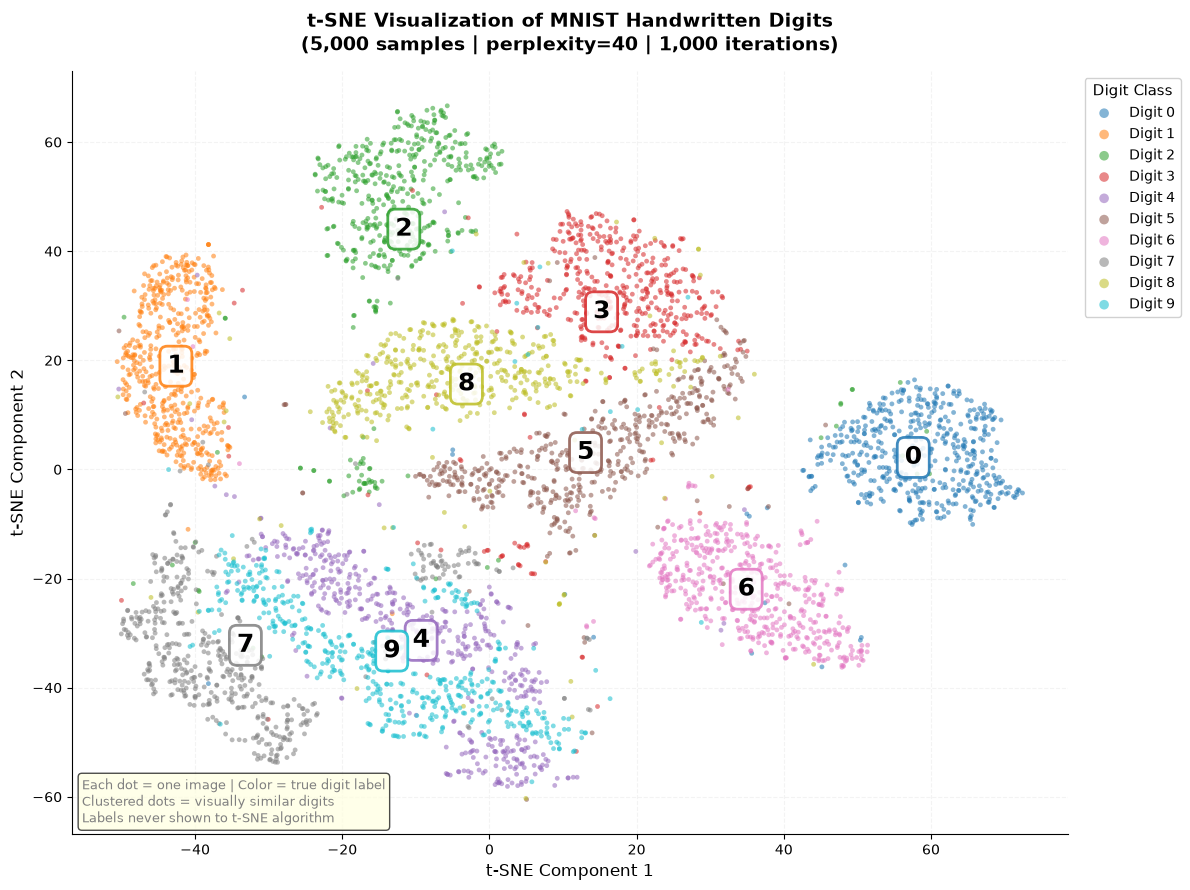

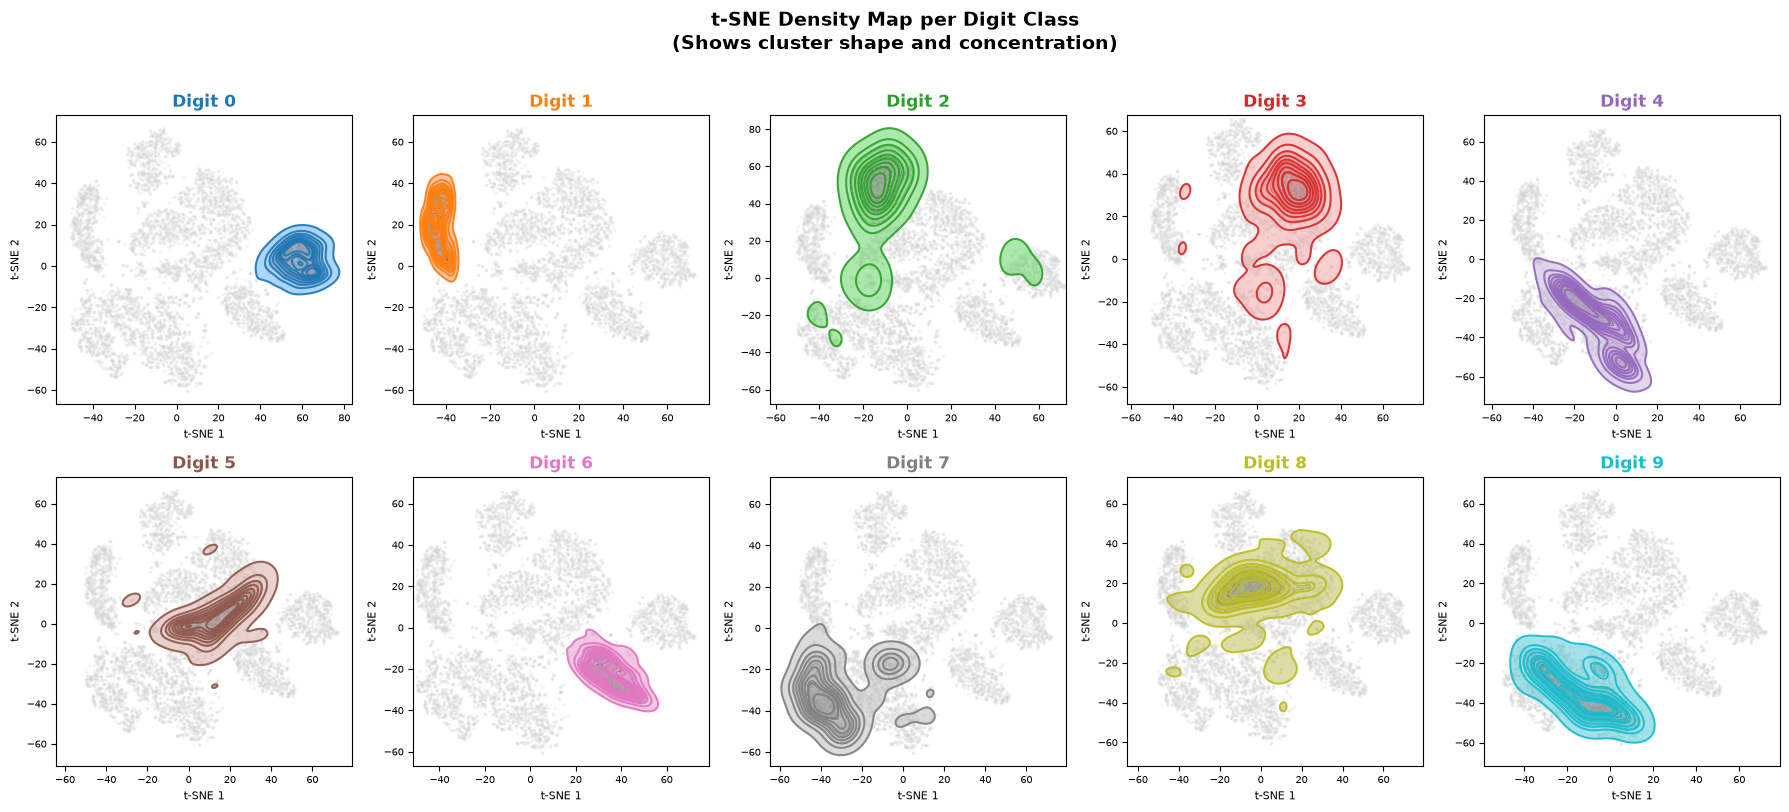


🔍 Observations:
   1. Digits 0, 1, 6 typically form the tightest clusters (most consistently written)
   2. Digits 4 and 9 often overlap (they look similar)
   3. Digits 3 and 8 may be close (similar curved strokes)
   4. Digit 1 is usually well-separated (unique vertical stroke)


In [8]:
# ============================================================
# CELL 13 (Code): Professional Visualizations
# ============================================================

# Define a consistent color palette for digits 0-9
palette = sns.color_palette('tab10', 10)

# =======================================================
# PLOT 1: Main t-SNE Scatter Plot (scikit-learn, 5000 pts)
# =======================================================

fig, ax = plt.subplots(figsize=(12, 9))

for digit in range(10):
    mask = y == digit
    ax.scatter(
        Y_lib[mask, 0],
        Y_lib[mask, 1],
        c=[palette[digit]],
        label=f'Digit {digit}',
        alpha=0.55,
        s=12,
        edgecolors='none'
    )

# Add digit labels at cluster centroids
for digit in range(10):
    mask = y == digit
    cx = Y_lib[mask, 0].mean()
    cy = Y_lib[mask, 1].mean()
    ax.text(cx, cy, str(digit), fontsize=18, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=palette[digit], linewidth=2, alpha=0.85))

ax.set_title('t-SNE Visualization of MNIST Handwritten Digits\n'
             '(5,000 samples | perplexity=40 | 1,000 iterations)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)

legend = ax.legend(title='Digit Class', fontsize=10, title_fontsize=11,
                   markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left',
                   framealpha=0.9)

ax.grid(True, alpha=0.15, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotation box
ax.text(0.01, 0.01,
        'Each dot = one image | Color = true digit label\n'
        'Clustered dots = visually similar digits\n'
        'Labels never shown to t-SNE algorithm',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', color='gray',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('tsne_main_plot.png', dpi=120, bbox_inches='tight')
plt.show()

# =======================================================
# PLOT 2: Density (KDE) Contour Plot per Digit
# =======================================================

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('t-SNE Density Map per Digit Class\n'
             '(Shows cluster shape and concentration)',
             fontsize=14, fontweight='bold', y=1.01)

for digit, ax in enumerate(axes.flat):
    mask = y == digit
    x_d = Y_lib[mask, 0]
    y_d = Y_lib[mask, 1]
    
    # Background scatter of all points (light gray)
    ax.scatter(Y_lib[:, 0], Y_lib[:, 1], c='lightgray', s=2, alpha=0.2)
    
    # KDE contour for this digit
    try:
        sns.kdeplot(x=x_d, y=y_d, ax=ax,
                    fill=True, alpha=0.5,
                    color=palette[digit],
                    levels=5, warn_singular=False)
        sns.kdeplot(x=x_d, y=y_d, ax=ax,
                    fill=False, alpha=0.9,
                    color=palette[digit],
                    linewidths=1.5, warn_singular=False)
    except Exception:
        # Fallback if KDE fails
        ax.scatter(x_d, y_d, c=[palette[digit]], s=5, alpha=0.6)
    
    ax.set_title(f'Digit {digit}', fontsize=12, fontweight='bold',
                 color=palette[digit])
    ax.set_xlabel('t-SNE 1', fontsize=8)
    ax.set_ylabel('t-SNE 2', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('tsne_density_plots.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n🔍 Observations:")
print("   1. Digits 0, 1, 6 typically form the tightest clusters (most consistently written)")
print("   2. Digits 4 and 9 often overlap (they look similar)")
print("   3. Digits 3 and 8 may be close (similar curved strokes)")
print("   4. Digit 1 is usually well-separated (unique vertical stroke)")

---
# 🎛️ Cell 14: Hyperparameter Discussion

t-SNE has several knobs you can turn. Understanding them is **critical for interviews and real-world use**.

---

## 1. `perplexity` (Most Important!)

**Meaning:** Controls how many neighbors each point considers when building its probability distribution. Roughly: "how many close friends should each point have?"

**Mathematically:** Sets the effective number of neighbors (via the entropy condition in binary search for σ)

| Perplexity Value | Effect | When to Use |
|---|---|---|
| 5–10 (low) | Focuses on very local structure; many small clusters | Small datasets (<1,000) |
| 30–50 (medium) | Balances local and global structure | Most cases |
| 100+ (high) | Emphasizes global structure; fewer, larger clusters | Very large datasets |

> 🎸 **Band Analogy:** Perplexity = the size of a friend group. Small perplexity = everyone only knows 5 friends (tight cliques). Large perplexity = everyone knows 100 friends (broader communities).

---

## 2. `n_iter` (Iterations)

**Meaning:** How many gradient descent steps to run.

- Too few (< 250): Map hasn't converged — clusters still mixed
- Too many (> 5000): Diminishing returns, much slower
- **Rule of thumb:** Start with 1,000; increase if clusters look noisy

---

## 3. `learning_rate`

**What is it?** The step size used when gradient descent updates each point's position in the 2D map. Think of it like adjusting the zoom on a GPS recalculation — too zoomed-out and you overshoot; too zoomed-in and you creep forward.

**Why does it matter?** If the learning rate is wrong, the algorithm either crawls forever or bounces chaotically and never finds good clusters.

**How to set it:**
- Too small: Converges very slowly; may not separate clusters even after 1,000 iterations
- Too large: Overshoots; produces a "ball of points" where everything collapses to the center
- **Modern default:** Use `learning_rate='auto'` (scikit-learn sets it to `max(N/12, 50)` where N = number of samples)

**When to manually tune:** Only if you see a "ball" output (increase) or no visible convergence (decrease). Otherwise, always start with `'auto'`.

---

## 4. `init` (Initialization)

**Options:** `'random'` or `'pca'`
- `'pca'` initialization: More stable, reproducible, recommended
- `'random'` initialization: Can lead to very different maps each run

---

## 5. `n_components`

Almost always 2 (for 2D scatter plot). Can use 3 for 3D visualization.

---

> ⚠️ **Critical Interview Warning:** t-SNE distances are **NOT interpretable globally**. Two clusters that look close on the t-SNE map may not actually be similar. The shapes and sizes of clusters are also **artifacts of the algorithm**, not meaningful data properties. Only the fact that points **cluster together** is meaningful.

🔬 Running perplexity experiments on 1,500 samples...
   (This runs 4 separate t-SNE fits — may take 3-5 minutes)

   Running perplexity=5... Done in 3.8s | KL=1.359
   Running perplexity=20... Done in 5.9s | KL=1.266
   Running perplexity=50... Done in 7.4s | KL=1.123
   Running perplexity=100... Done in 10.1s | KL=0.971


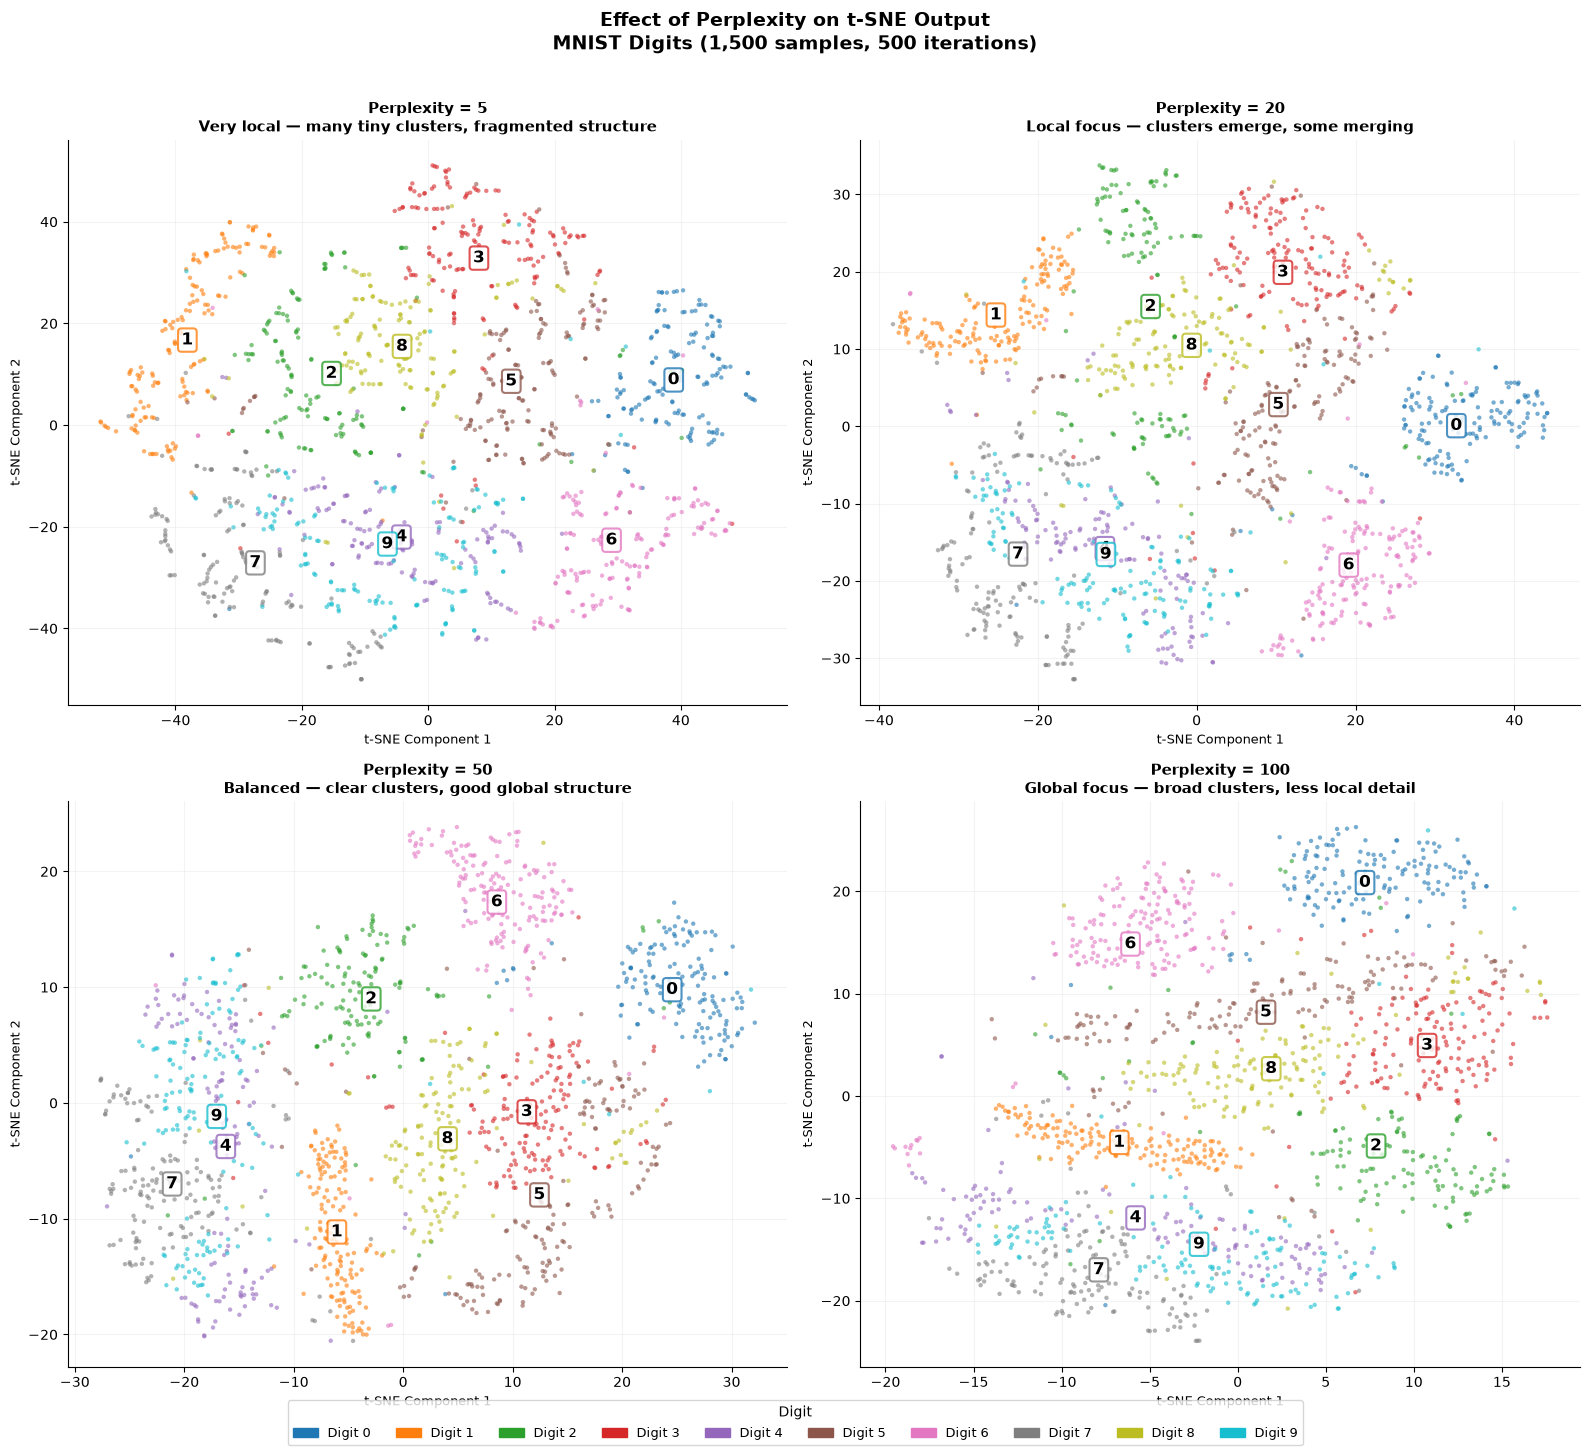


📌 Key Observation:
   • perplexity=5  → Too local; digits appear fragmented
   • perplexity=50 → Usually the sweet spot for MNIST
   • perplexity=100→ Clusters collapse; less informative
   • Always try multiple perplexity values — there's no single best choice!


In [9]:
# ============================================================
# CELL 15 (Code): Hyperparameter Experiments
# ============================================================
# We compare t-SNE with 4 different perplexity values on 1,500 samples

print("🔬 Running perplexity experiments on 1,500 samples...")
print("   (This runs 4 separate t-SNE fits — may take 3-5 minutes)\n")

# Use 1500 samples for the experiment (balance of speed vs quality)
N_EXP = 1500
X_exp = X_pca[:N_EXP]
y_exp = y[:N_EXP]

perplexity_values = [5, 20, 50, 100]
embeddings_exp = {}

for perp in perplexity_values:
    print(f"   Running perplexity={perp}...", end=' ')
    t0 = time.time()
    tsne_exp = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=500,
        learning_rate='auto',
        init='pca',
        random_state=42,
        verbose=0
    )
    Y_exp = tsne_exp.fit_transform(X_exp)
    embeddings_exp[perp] = Y_exp
    t1 = time.time()
    print(f"Done in {t1-t0:.1f}s | KL={tsne_exp.kl_divergence_:.3f}")

# --- Plot comparison ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Effect of Perplexity on t-SNE Output\n'
             'MNIST Digits (1,500 samples, 500 iterations)',
             fontsize=14, fontweight='bold', y=1.01)

descriptions = {
    5:   'Very local — many tiny clusters, fragmented structure',
    20:  'Local focus — clusters emerge, some merging',
    50:  'Balanced — clear clusters, good global structure',
    100: 'Global focus — broad clusters, less local detail'
}

for ax, perp in zip(axes.flat, perplexity_values):
    Y = embeddings_exp[perp]
    
    for digit in range(10):
        mask = y_exp == digit
        ax.scatter(Y[mask, 0], Y[mask, 1],
                   c=[palette[digit]], label=f'{digit}',
                   alpha=0.6, s=10, edgecolors='none')
    
    # Add cluster labels
    for digit in range(10):
        mask = y_exp == digit
        cx, cy = Y[mask, 0].mean(), Y[mask, 1].mean()
        ax.text(cx, cy, str(digit), fontsize=12, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor=palette[digit], linewidth=1.5, alpha=0.8))
    
    ax.set_title(f'Perplexity = {perp}\n{descriptions[perp]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Component 1', fontsize=9)
    ax.set_ylabel('t-SNE Component 2', fontsize=9)
    ax.grid(True, alpha=0.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add shared legend
handles = [mpatches.Patch(color=palette[d], label=f'Digit {d}') for d in range(10)]
fig.legend(handles=handles, title='Digit', loc='lower center',
           ncol=10, fontsize=9, title_fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('tsne_perplexity_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📌 Key Observation:")
print("   • perplexity=5  → Too local; digits appear fragmented")
print("   • perplexity=50 → Usually the sweet spot for MNIST")
print("   • perplexity=100→ Clusters collapse; less informative")
print("   • Always try multiple perplexity values — there's no single best choice!")

---
# 📏 Cell 16: Evaluation of t-SNE Embeddings

## Why evaluate t-SNE?

Unlike classification models (where we use accuracy), t-SNE is **unsupervised** — there's no direct "correct answer" for the layout. However, we can evaluate how well the 2D embedding **preserves the structure** of the original data.

## Methods we'll use:

### 1. Trustworthiness Score
Measures how well the **neighborhood structure** is preserved. A trustworthiness of 1.0 means every point's nearest neighbors in 2D are also its nearest neighbors in the original space.

- **Score > 0.90** → Excellent
- **Score 0.80–0.90** → Good
- **Score < 0.80** → Poor preservation

### 2. KNN Classification Accuracy on t-SNE Embeddings
We train a simple K-Nearest Neighbors classifier on the t-SNE 2D embeddings. If the embeddings are good, **similar digits cluster together**, and even a simple classifier should do well.

This is a **practical proxy metric**: if a KNN trained on t-SNE features scores high, the embedding is good.

> ⚠️ **Caution:** This is only for evaluation. Never use t-SNE features as input to a production model — t-SNE cannot transform new, unseen data.

## How to interpret the evaluation results:

**Trustworthiness Score:**
- Score of 1.00 = perfect — every point's 10 nearest neighbors in 2D are exactly its 10 nearest neighbors in 50-D PCA space
- Score of 0.95+ = excellent for MNIST (typical expected range)
- Score below 0.85 = the embedding is distorting local structure significantly

**KNN Accuracy on t-SNE 2D:**
- Expected: 90–96% for MNIST at perplexity=40, 5,000 samples
- If this is much lower than raw-pixel KNN: the t-SNE embedding lost important information
- If it's similar: t-SNE preserved the class-separating structure despite discarding 782 dimensions

**Confusion Matrix:**
- Dark diagonal = good predictions (the model correctly identifies that digit)
- Off-diagonal bright cells = common confusions — typically 4↔9, 3↔8, 5↔6
- These confusions reflect genuine visual similarity — the same mistakes humans make with messy handwriting

📊 Evaluating t-SNE embedding quality...

⚙️  Computing Trustworthiness (on 1000 samples, n_neighbors=10)...
   Trustworthiness Score: 0.9591
   ✅ Excellent — neighborhoods well preserved

⚙️  KNN Classification on t-SNE 2D embeddings...
   KNN (k=5) Accuracy on t-SNE 2D: 93.8% ± 1.0%
   Individual fold scores: ['0.923', '0.941', '0.933', '0.953', '0.941']

   KNN (k=5) Accuracy on raw pixels (subset): 89.4% ± 2.6%


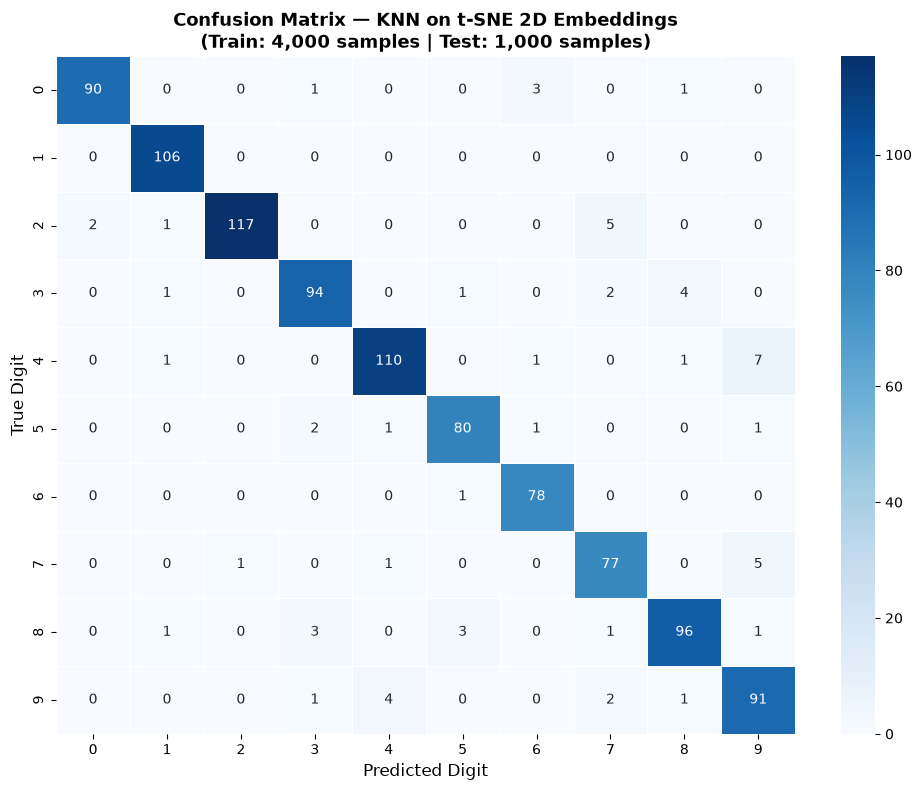


📋 Evaluation Summary:
                           Metric           Score
 Trustworthiness (n_neighbors=10)          0.9591
KNN Accuracy on t-SNE 2D (5-fold) 0.9382 ± 0.0099
       KNN Accuracy on raw pixels 0.8940 ± 0.0256

🔍 Interpretation:
   • High trustworthiness = t-SNE preserves local neighborhoods well
   • KNN accuracy on 2D embeddings close to raw-pixel KNN = embedding is informative
   • Common confusions: 4↔9, 3↔8, 5↔6 (look similar in handwriting)


In [10]:
# ============================================================
# CELL 17 (Code): Quantitative Evaluation of t-SNE
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import trustworthiness
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

print("📊 Evaluating t-SNE embedding quality...\n")

# --- 1. Trustworthiness Score ---
# Uses a subset for speed (trustworthiness is O(n²))
N_TRUST = 1000
print(f"⚙️  Computing Trustworthiness (on {N_TRUST} samples, n_neighbors=10)...")

trust_score = trustworthiness(
    X_pca[:N_TRUST],    # Original high-dim space (after PCA)
    Y_lib[:N_TRUST],    # 2D t-SNE embedding
    n_neighbors=10
)

print(f"   Trustworthiness Score: {trust_score:.4f}")
if trust_score > 0.90:
    print("   ✅ Excellent — neighborhoods well preserved")
elif trust_score > 0.80:
    print("   ✅ Good — neighborhoods mostly preserved")
else:
    print("   ⚠️  Poor — significant neighborhood distortion")

# --- 2. KNN Classification on t-SNE Embeddings ---
print(f"\n⚙️  KNN Classification on t-SNE 2D embeddings...")

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# 5-fold cross-validation
cv_scores = cross_val_score(knn, Y_lib, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"   KNN (k=5) Accuracy on t-SNE 2D: {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")
print(f"   Individual fold scores: {[f'{s:.3f}' for s in cv_scores]}")

# --- Baseline: KNN on raw pixels ---
N_KNN = 2000   # Subset for speed
knn_baseline = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
cv_baseline = cross_val_score(knn_baseline, X_normalized[:N_KNN], y[:N_KNN],
                              cv=5, scoring='accuracy', n_jobs=-1)
print(f"\n   KNN (k=5) Accuracy on raw pixels (subset): {cv_baseline.mean()*100:.1f}% ± {cv_baseline.std()*100:.1f}%")

# --- 3. Confusion Matrix on t-SNE embeddings ---
knn.fit(Y_lib[:4000], y[:4000])
y_pred = knn.predict(Y_lib[4000:])
y_true = y[4000:]

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — KNN on t-SNE 2D Embeddings\n'
             '(Train: 4,000 samples | Test: 1,000 samples)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Digit', fontsize=12)
ax.set_ylabel('True Digit', fontsize=12)
plt.tight_layout()
plt.savefig('tsne_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Summary table
print("\n📋 Evaluation Summary:")
summary = pd.DataFrame({
    'Metric': ['Trustworthiness (n_neighbors=10)',
               'KNN Accuracy on t-SNE 2D (5-fold)',
               'KNN Accuracy on raw pixels'],
    'Score': [f"{trust_score:.4f}",
              f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
              f"{cv_baseline.mean():.4f} ± {cv_baseline.std():.4f}"]
})
print(summary.to_string(index=False))

print("\n🔍 Interpretation:")
print("   • High trustworthiness = t-SNE preserves local neighborhoods well")
print("   • KNN accuracy on 2D embeddings close to raw-pixel KNN = embedding is informative")
print("   • Common confusions: 4↔9, 3↔8, 5↔6 (look similar in handwriting)")

---
# 🎤 Cell 18: Interview Corner

## Top 12 t-SNE Interview Questions (with Answers)

---

### Q1: What does t-SNE stand for and what does it do?
**Answer:** t-distributed Stochastic Neighbor Embedding. It maps high-dimensional data to 2D/3D while preserving local neighborhood structure — primarily for visualization.

---

### Q2: What is the role of perplexity in t-SNE?
**Answer:** Perplexity controls the effective number of neighbors each point considers. It's roughly the size of the local neighborhood. Low perplexity = focus on very local structure. High perplexity = include broader global structure. Typical range: 5–50.

---

### Q3: Why does t-SNE use a t-distribution in low-dimensional space instead of a Gaussian?
**Answer:** In high dimensions, the "curse of dimensionality" makes most distances similar. The t-distribution's heavier tails allow points with moderate distance in high-D to be placed much farther apart in 2D, creating well-separated, clearly visible clusters.

---

### Q4: Can you use t-SNE features as input to a downstream classifier?
**Answer:** No! t-SNE is a non-parametric method — it cannot transform new/unseen data without rerunning the entire algorithm. Also, global distances in t-SNE space are not meaningful. Use PCA or UMAP if you need transformable embeddings.

---

### Q5: What is KL divergence in the context of t-SNE?
**Answer:** KL divergence measures how different the 2D probability distribution Q is from the high-dimensional distribution P. t-SNE minimizes KL(P||Q). KL divergence is asymmetric: it heavily penalizes placing nearby high-D points far apart in 2D (more than the reverse).

---

### Q6: What is early exaggeration in t-SNE?
**Answer:** In the first ~100 iterations, the high-dimensional probabilities P are multiplied by a factor (typically 4 or 12). This makes clusters "pull" together more strongly early on, helping the algorithm form well-separated clusters before fine-tuning.

---

### Q7: Why is t-SNE non-deterministic?
**Answer:** t-SNE initializes embeddings randomly and uses stochastic gradient descent. Different random seeds produce different layouts. The topology (which clusters exist) is consistent, but their exact position and orientation vary. Use `random_state` for reproducibility.

---

### Q8: What are the computational limitations of t-SNE?
**Answer:** Naive t-SNE is O(n²) in time and memory — impractical for >10,000 samples. Barnes-Hut t-SNE approximates the repulsive forces to O(n log n), making it feasible up to ~100,000 samples.

---

### Q9: How does t-SNE differ from PCA?
**Answer:**
- PCA is **linear**, t-SNE is **non-linear**
- PCA preserves global variance; t-SNE preserves local neighborhood structure
- PCA is fast and deterministic; t-SNE is slow and stochastic
- PCA can transform new data; t-SNE cannot
- Best practice: apply PCA first (784→50), then t-SNE (50→2)

---

### Q10: What is the Crowding Problem in t-SNE?
**Answer:** When mapping from high to low dimensions, moderate-distance points in high-D space have nowhere to go in 2D — they'd crowd the center. The t-distribution's heavy tails solve this by allowing these points to be pushed far out, creating distinct clusters.

---

### Q11: What is UMAP and how does it compare to t-SNE?
**Answer:** UMAP (Uniform Manifold Approximation and Projection) is a newer alternative. It's **faster** than t-SNE, **better preserves global structure**, can transform new data, and is based on Riemannian geometry. t-SNE still often gives slightly better local cluster separation for visualization.

---

### Q12: Can t-SNE be used for feature extraction / dimensionality reduction for machine learning?
**Answer:** Generally **no**, for three reasons:
1. Cannot transform unseen data
2. Global distances are not meaningful
3. Results change with every run (stochastic)

Use PCA, UMAP, or autoencoders for ML preprocessing. Use t-SNE only for **exploration and visualization**.

---

### Q13: What is "early exaggeration" in t-SNE and why does it help?
**Answer:** In the first ~100–250 iterations, scikit-learn multiplies all $p_{ij}$ values by a constant (default: 12). This temporarily makes the high-dimensional probabilities much larger, which forces clusters to pull strongly together early in training. The effect: the algorithm forms well-separated, tight clusters quickly before the fine-tuning phase begins. Without early exaggeration, clusters may merge or never fully separate.

---

### Q14: What is the Barnes-Hut approximation and why does it matter?
**Answer:** Naive t-SNE computes exact repulsive forces between all n² pairs of points — O(n²) complexity. Barnes-Hut groups distant points into spatial "cells" and approximates their combined repulsion as if they were a single point. This reduces complexity to O(n log n), making t-SNE feasible on datasets of up to ~100,000 samples. Scikit-learn uses Barnes-Hut by default. The trade-off: slightly less accurate than exact t-SNE, but typically indistinguishable visually.

---

### Q15: A recruiter asks "How do you know if your t-SNE plot is trustworthy?" — what do you say?
**Answer:** Four checks:
1. **Run at multiple perplexities (5, 30, 100)** — clusters that appear consistently across all three are real, not artifacts
2. **Run with multiple random seeds** — if the overall topology (which groups exist) is consistent, the structure is meaningful
3. **Check the trustworthiness score** — above 0.90 means local neighborhoods are well preserved
4. **Validate with a downstream task** — train a KNN on the 2D embeddings; if accuracy is reasonable, the embedding is informative

---
# ✅ Cell 19: When Should You Use t-SNE?

## Decision Guide

> 🔀 **Quick Decision Flow:** *Do you need to visualize high-dimensional data?* → Yes → *Is your dataset under 100k samples?* → Yes → *Do you need to transform new points later?* → No → **Use t-SNE**. Yes → **Use UMAP**. No to dataset size → **Use UMAP**. No to visualization → **Use PCA or UMAP**.

| Situation | Use t-SNE? | Better Alternative |
|---|---|---|
| Exploring if clusters exist in data | ✅ Yes | — |
| Visualizing word embeddings (NLP) | ✅ Yes | UMAP |
| Visualizing image feature maps | ✅ Yes | UMAP |
| Detecting outliers visually | ✅ Yes | Isolation Forest |
| Preprocessing for a classifier | ❌ No | PCA, UMAP |
| Dataset > 100,000 samples | ❌ No | UMAP |
| Need to transform new data | ❌ No | PCA, UMAP |
| Need globally interpretable distances | ❌ No | PCA, MDS |
| Need fast, deterministic results | ❌ No | PCA |
| Production ML pipeline feature | ❌ Never | PCA, UMAP, Autoencoders |

## Real-World Use Cases

| Industry | Use Case |
|---|---|
| **Biology / Genomics** | Visualizing single-cell RNA sequencing data to find cell types |
| **NLP** | Visualizing word2vec or BERT embeddings to see semantic clusters |
| **Computer Vision** | Checking if CNN feature spaces separate classes correctly |
| **Drug Discovery** | Visualizing molecular fingerprints to find similar compounds |
| **Fraud Detection** | Visually inspecting if fraud transactions cluster distinctly |
| **Customer Analytics** | Exploratory clustering of customer behavior vectors |
| **Anomaly Detection** | Finding points far from all clusters = potential anomalies |

---
# 📐 Cell 20: Practical Rules of Thumb

## The t-SNE Practitioner's Cheat Sheet

---

### 🔵 Before Running t-SNE:
- **Always normalize/scale your features first** — otherwise large-scale features dominate
- **Run PCA first to ~50 dimensions** — removes noise, dramatically speeds up t-SNE
- **Subsample large datasets** — t-SNE on >50k points becomes very slow
- **Check for obvious outliers** — extreme outliers distort the embedding

---

### 🟡 Choosing Hyperparameters:
- **Perplexity:** Start at 30–50. Try at least 3 values. Perplexity should be less than the number of samples.
- **Iterations:** At least 750. Use 1,000+ for production visualization.
- **Learning rate:** Use `'auto'` (scikit-learn ≥ 1.2). If manual: N/12 where N = sample count.
- **Initialization:** Use `init='pca'` for stable, reproducible starts.

---

### 🔴 Interpreting Results:
- **Cluster existence is meaningful** — clusters you see are real
- **Cluster SIZE is NOT meaningful** — don't conclude one group is "bigger"
- **Cluster DISTANCE is NOT meaningful** — nearby clusters may not be similar globally
- **Always run with multiple random seeds** — if clusters appear consistently, they're real
- **A cluster split into subclusters at low perplexity** — not necessarily meaningful

---

### 🟢 Pro Tips:
- Color your points by multiple variables (labels, confidence scores, features) to gain deeper insight — one t-SNE plot, multiple stories
- Use t-SNE + cluster algorithms (DBSCAN, HDBSCAN) together: t-SNE finds the visual shape, DBSCAN finds the algorithmic boundaries
- When showing to non-technical stakeholders, explain that axes have **no inherent meaning** — only relative positions matter. Say: *"Think of it like a city map — which neighborhoods are near each other matters; the compass direction does not."*
- Consider **UMAP** if you need faster runtime or to transform new data — UMAP is faster, preserves global structure better, and handles larger datasets
- **Never run t-SNE and immediately share the result** — always cross-check with 2–3 different perplexity values first. A result that looks clean with perplexity=30 but collapses with perplexity=5 may be an artifact, not a real cluster.
- **Save your embeddings to disk** (`np.save`) before running downstream analysis — re-running t-SNE won't give the same result, so save the output you analyzed

---
# 🎓 Cell 21: Key Takeaways

---

## The 5 Things to Remember About t-SNE

1. 🔬 **t-SNE is a non-linear visualization technique** that compresses high-dimensional data (hundreds/thousands of features) into 2D while keeping similar points close together — it does this by matching probability distributions in high-D and low-D spaces using KL divergence minimization.

2. 🎛️ **Perplexity is the most important hyperparameter** — it controls the neighborhood size each point considers. Always experiment with 3–5 values (typically 5, 20, 40, 80) since the same dataset can look very different at different perplexities, and no single value is universally best.

3. ⚠️ **t-SNE is for visualization only, not for production features** — it cannot transform new/unseen data, global distances are not meaningful, and results are stochastic. For feature extraction or preprocessing, use PCA or UMAP instead.

4. 🚀 **The right workflow is PCA → t-SNE** — first reduce to ~50 dimensions with PCA (fast, removes noise), then apply t-SNE (50→2). This is faster and gives cleaner results than applying t-SNE directly to raw high-dimensional data.

5. 🌍 **t-SNE is widely used in cutting-edge research** — from single-cell genomics and drug discovery to NLP and computer vision, it remains one of the most trusted tools for exploring structure in complex datasets, even as newer alternatives like UMAP gain popularity.

6. 🗺️ **Interpret outputs carefully** — in a t-SNE plot, cluster existence is meaningful, but cluster size, distance between clusters, and axis values are NOT. Always run multiple seeds and perplexities before drawing conclusions. Two plots of the same data at different perplexities can look completely different and both be "correct."

---

## 🧠 One-Line Memory Aid

> **"t-SNE squishes dimensions by matching who's neighbors with who — using bell curves in high-D and heavy-tailed curves in 2D — and it's only for your eyes, not for your model."**

---

## 📚 Further Reading

| Resource | Link |
|---|---|
| Original t-SNE Paper (Maaten & Hinton, 2008) | [JMLR PDF](https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) |
| How to Use t-SNE Effectively (Wattenberg et al.) | [Distill.pub](https://distill.pub/2016/misread-tsne/) |
| scikit-learn t-SNE Documentation | [sklearn.manifold.TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) |
| UMAP: The Modern Alternative | [UMAP GitHub](https://github.com/lmcinnes/umap) |
| Understanding the Crowding Problem | [Maaten's Blog](https://lvdmaaten.github.io/tsne/) |

---

> 💬 *"All models are wrong, but some are useful."* — George Box
>
> t-SNE is not perfect — but when used correctly, it's one of the most powerful lenses for seeing structure in complex data. Now you know how to use it wisely. 🎉

---
*Notebook by: Senior ML Engineer & MIT Educator | Dataset: MNIST via OpenML | Last updated: 2025*